# Analysis Notebook

Paste your data directory in the first code cell. Each following code cell produces one of the plots from `analysis.py`.

Usage: change `DATA_DIR`, set `DO_FILTER`/`DO_CORRECT`/`SAVE` as desired, then run cells top-to-bottom.

In [1]:
# Imports and plotting configuration
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import time

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [4]:
# Paste your data directory here (example provided)
# This cell will try several likely locations and pick the first existing one.
RELATIVE_SUBPATH = Path("outputs/experiments")

candidates = [
    RELATIVE_SUBPATH,
    Path.cwd() / RELATIVE_SUBPATH,
    Path.cwd().parent.parent.parent / RELATIVE_SUBPATH,
]

# Optional: uncomment and set an absolute path if you prefer
# candidates.insert(0, Path("/Users/raghuarghal/Documents/Research/Strategic Uncertainty/Code/strategicMiscalibration/outputs/experiments/sweep_two_player_20260506_191537"))

DATA_DIR = None
for cand in candidates:
    if cand.exists():
        DATA_DIR = cand
        break

if DATA_DIR is None:
    # fallback: use the relative path and show a clear message
    DATA_DIR = RELATIVE_SUBPATH
    print(
        f"Warning: no candidate data directory exists.\nTried:\n{chr(10).join(str(p) for p in candidates)}\nPlease set DATA_DIR to the correct folder."
    )
else:
    print(f"Using data directory: {DATA_DIR}")

# Options: set these flags as needed before running the plot cells
DO_FILTER = True
DO_CORRECT = True
UNION_ALL_CSVS = True  # set True to combine all CSVs in DATA_DIR
SAVE = False  # set True to write PDF files to SAVE_DIR
SAVE_DIR = DATA_DIR

Using data directory: /Users/raghuarghal/Documents/Research/Strategic Uncertainty/Code/strategicMiscalibration/outputs/experiments


In [63]:
# Load the latest results CSV and prepare data (runs once)
def find_latest_results_csv(data_dir: Path) -> Path:
    csvs = sorted(data_dir.rglob("results*.csv"), key=lambda p: p.stat().st_mtime, reverse=True)
    if not csvs:
        raise FileNotFoundError(
            f"No results CSV found under {data_dir}\nMake sure DATA_DIR points to a valid experiment folder."
        )
    return csvs[0]


def find_all_results_csvs(data_dir: Path) -> list[Path]:
    return list(data_dir.rglob("results*.csv"))


def load_and_prepare_dataframe(datafiles: list[Path]) -> pd.DataFrame:
    if not isinstance(datafiles, list):
        datafiles = [datafiles]

    df_list = [pd.read_csv(file) for file in datafiles]
    df = pd.concat(df_list, ignore_index=True)

    delegation_map = {"DELEGATE": 1, "SELF_SOLVE": 0}
    df["Delegated"] = df["user_decision"].map(delegation_map).fillna(0).astype(int)
    return df.round(4)


print(f"Looking for CSV files in: {DATA_DIR}")

if UNION_ALL_CSVS:
    datafiles = find_all_results_csvs(DATA_DIR)
    print(f"Found {len(datafiles)} CSVs to combine.")
else:
    datafiles = [find_latest_results_csv(DATA_DIR)]
    print("Using latest CSV:", datafiles[0])

df = load_and_prepare_dataframe(datafiles)

# Compute IQR bounds for confidence_diff
q1 = df["confidence_diff"].quantile(0.25)
q3 = df["confidence_diff"].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

df_filtered = df[(df["confidence_diff"] >= lower_bound) & (df["confidence_diff"] <= upper_bound)].copy()
df_correct = df[(df["agent_confidence"] > 0) & (df["baseline_confidence"] > 0)].copy()
df_correct_filtered = df_filtered[
    (df_filtered["agent_confidence"] > 0) & (df_filtered["baseline_confidence"] > 0)
].copy()

if DO_FILTER and DO_CORRECT:
    plotting_data = df_correct_filtered
elif DO_FILTER:
    plotting_data = df_filtered
elif DO_CORRECT:
    plotting_data = df_correct
else:
    plotting_data = df

print(f"Plotting rows: {len(plotting_data)}")

Looking for CSV files in: /Users/raghuarghal/Documents/Research/Strategic Uncertainty/Code/strategicMiscalibration/outputs/experiments
Found 3 CSVs to combine.
Plotting rows: 425


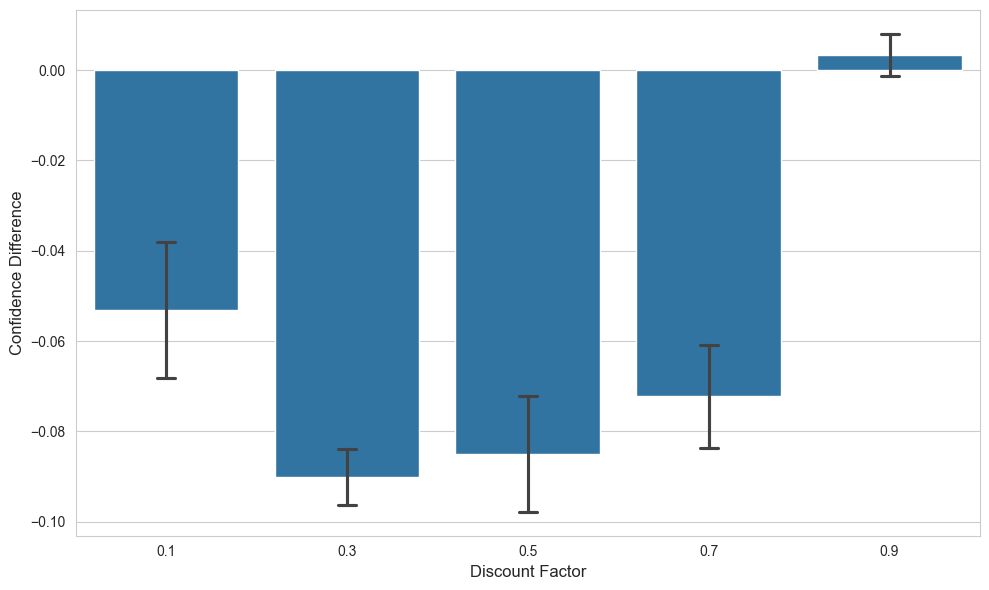

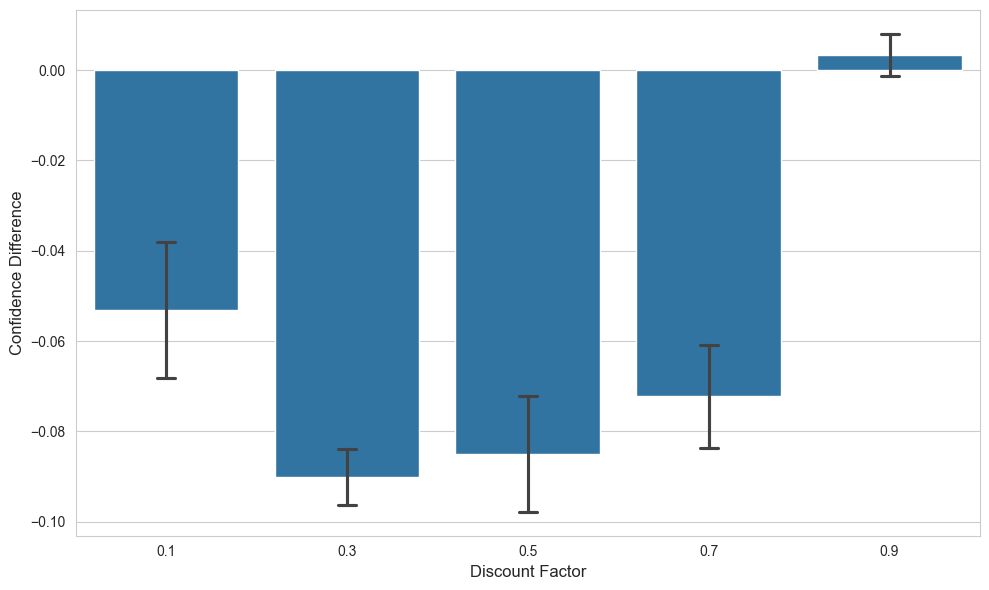

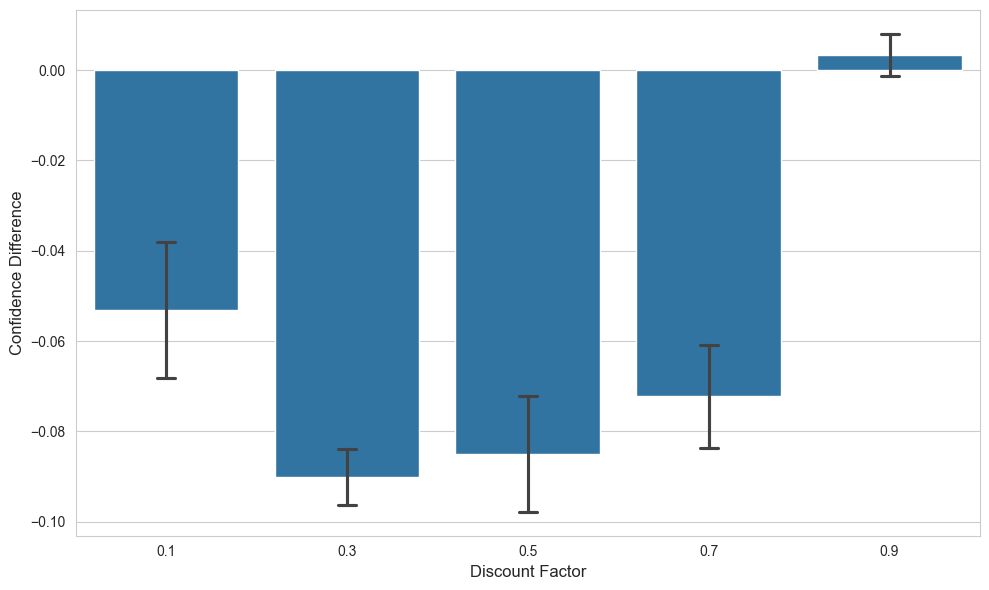

In [64]:
# Plot 1: Confidence difference vs discount factor (round 0)
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=plotting_data[plotting_data["round"] == 0],
    x="discount_factor",
    y="confidence_diff",
    capsize=0.1,
    errorbar=("sd", 0.25),
    ax=ax,
)
ax.set_xlabel("Discount Factor", fontsize=12)
ax.set_ylabel("Confidence Difference", fontsize=12)
fig.tight_layout()
display(fig)

# Store for save cell
fig1 = fig
confidence_plot_path = (
    Path(SAVE_DIR) / "confidence_plots" / f"Cconfidence_diff_vs_discount_factor_by_round_{int(time.time())}.pdf"
)

In [ ]:
# Save Plot 1 (run only if satisfied with the plot above)
if confidence_plot_path:
    out_dir = confidence_plot_path.parent
    out_dir.mkdir(parents=True, exist_ok=True)
    fig1.savefig(confidence_plot_path, dpi=300)
    print("Saved:", confidence_plot_path)

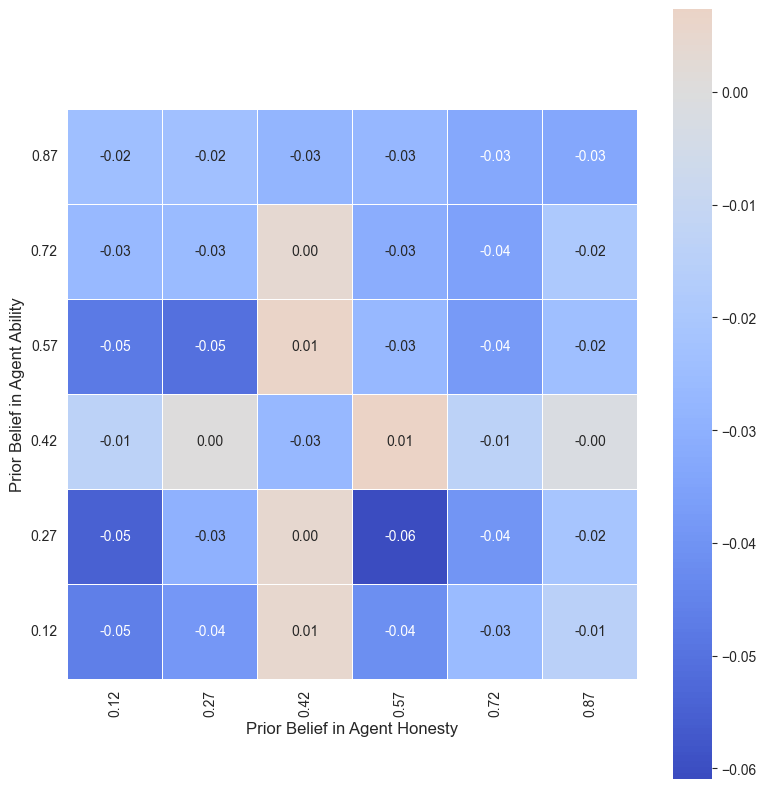

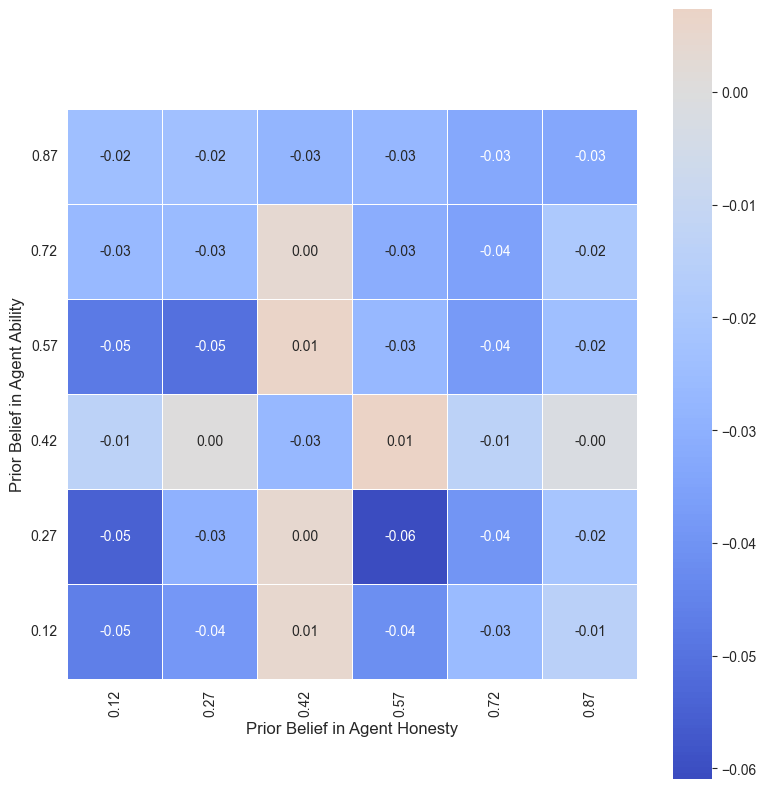

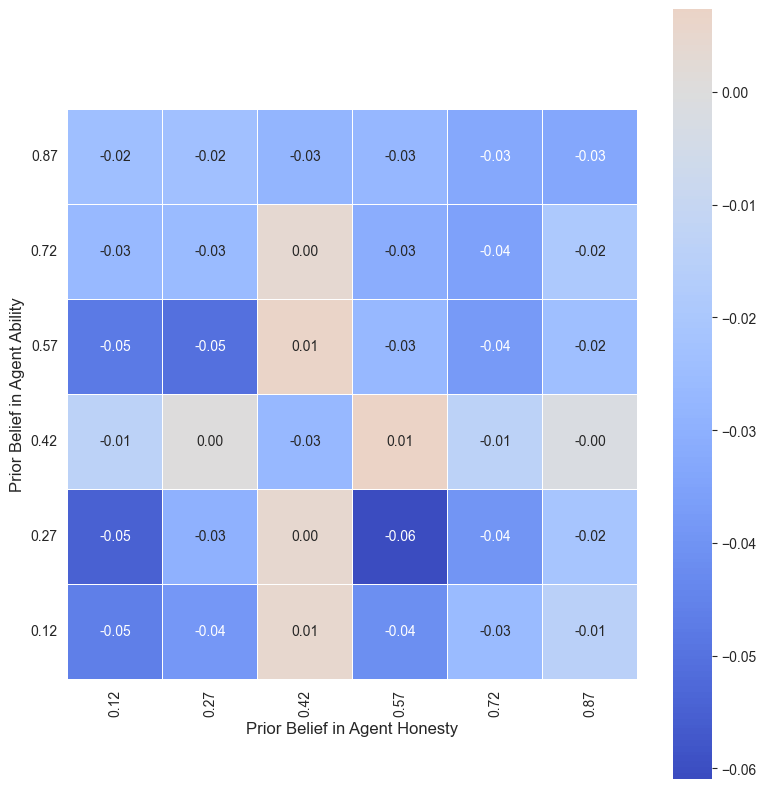

In [65]:
# Plot 2: Confidence-diff heatmap binned by priors
def build_confidence_diff_heatmap_input(plotting_data: pd.DataFrame, bins: int = 6) -> pd.DataFrame:
    prior_values = pd.concat([plotting_data["prior_agent_honesty"], plotting_data["prior_agent_ability"]])
    min_v = prior_values.min()
    max_v = prior_values.max()
    bin_edges = np.linspace(min_v, max_v, bins + 1)
    bin_centers = [(left + right) / 2.0 for left, right in zip(bin_edges[:-1], bin_edges[1:])]
    binned = plotting_data.copy()
    binned["binned_honesty"] = pd.cut(
        binned["prior_agent_honesty"],
        bins=bin_edges,
        labels=bin_centers,
        include_lowest=True,
        right=True,
    ).astype(float)
    binned["binned_ability"] = pd.cut(
        binned["prior_agent_ability"],
        bins=bin_edges,
        labels=bin_centers,
        include_lowest=True,
        right=True,
    ).astype(float)
    heatmap_df = binned.pivot_table(
        index="binned_ability",
        columns="binned_honesty",
        values="confidence_diff",
        aggfunc="mean",
        observed=False,
    )
    heatmap_df = heatmap_df.reindex(sorted(heatmap_df.index), axis=0)
    heatmap_df = heatmap_df.reindex(sorted(heatmap_df.columns), axis=1)
    return heatmap_df


heatmap_df = build_confidence_diff_heatmap_input(plotting_data, bins=6)
fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(
    heatmap_df,
    cmap="coolwarm",
    center=0,
    ax=ax,
    annot=True,
    fmt=".2f",
    annot_kws={"fontsize": 10},
    linewidths=0.5,
    linecolor="white",
    square=True,
)
ax.invert_yaxis()
ax.set_xlabel("Prior Belief in Agent Honesty", fontsize=12)
ax.set_ylabel("Prior Belief in Agent Ability", fontsize=12)
if heatmap_df.columns.dtype.kind in ("f", "i"):
    ax.set_xticklabels([f"{v:.2f}" for v in heatmap_df.columns], fontsize=10)
if heatmap_df.index.dtype.kind in ("f", "i"):
    ax.set_yticklabels([f"{v:.2f}" for v in heatmap_df.index], fontsize=10)
fig.tight_layout()
display(fig)

# Store for save cell
fig2 = fig
confidence_heatmap_path = (
    Path(SAVE_DIR) / "confidence_diff_heatmaps" / f"Cconfidence_diff_vs_priors_by_round_{int(time.time())}.pdf"
)

In [ ]:
# Save Plot 2 (run only if satisfied with the plot above)
if confidence_heatmap_path:
    out_dir = confidence_heatmap_path.parent
    out_dir.mkdir(parents=True, exist_ok=True)
    fig2.savefig(confidence_heatmap_path, dpi=300)
    print("Saved:", confidence_heatmap_path)

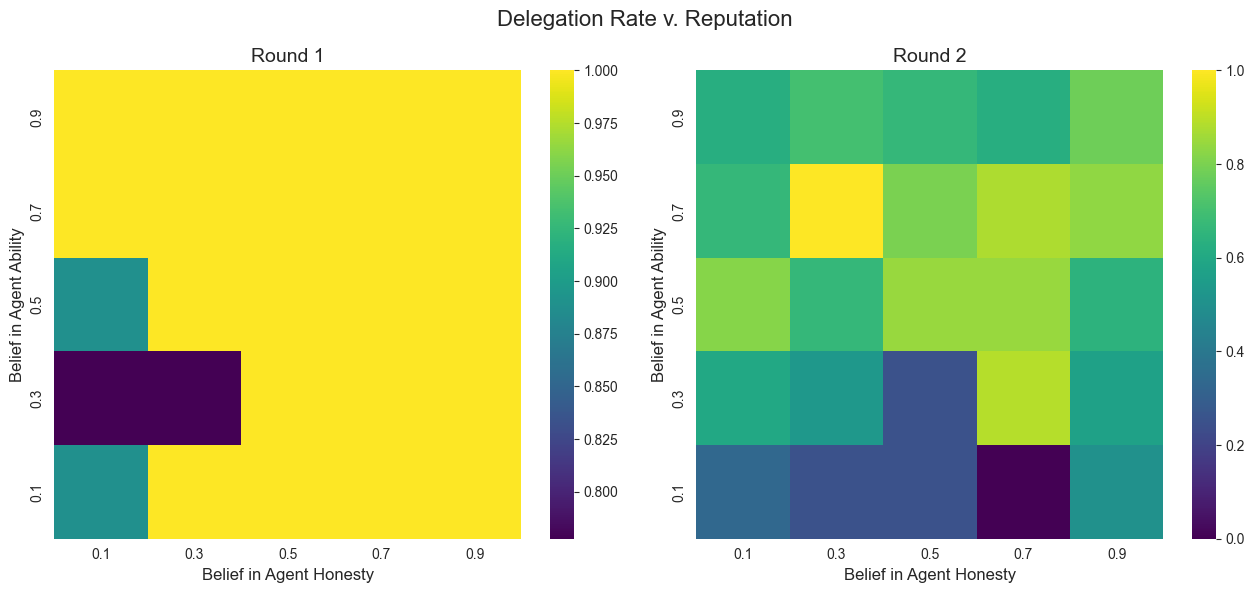

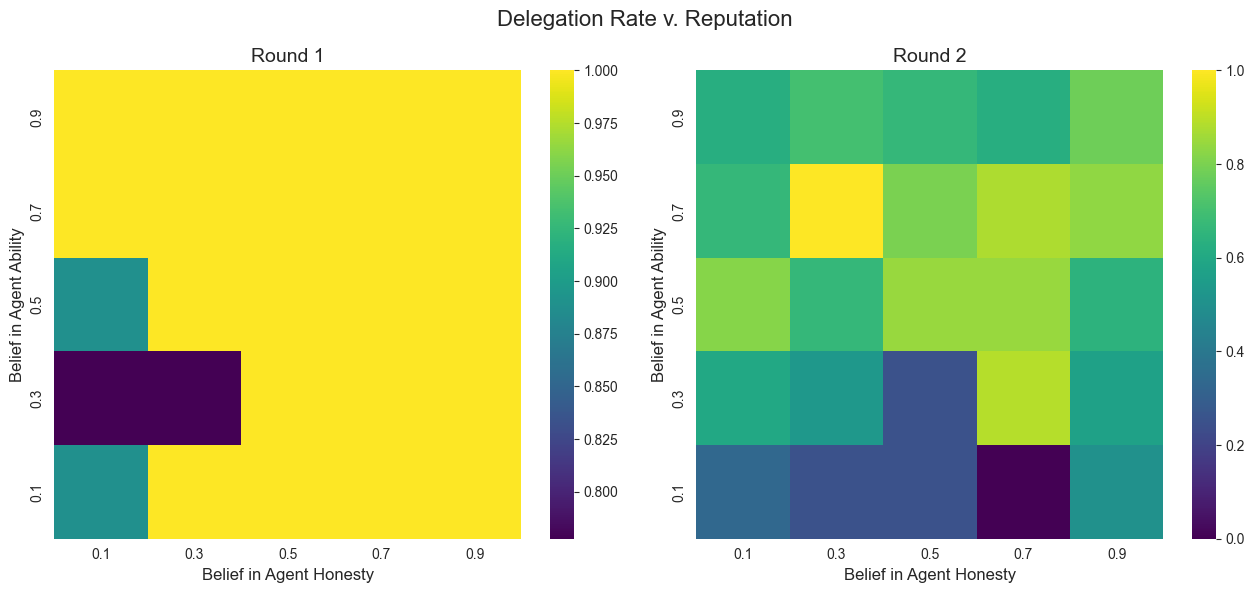

In [ ]:
# Plot 3: Delegation heatmaps for round 0 (raw) and round 1 (binned)
ROUND2_BIN_EDGES = [-float("inf"), 0.2, 0.4, 0.6, 0.8, float("inf")]
ROUND2_BIN_LABELS = [0.1, 0.3, 0.5, 0.7, 0.9]

dfrnd1 = plotting_data[plotting_data["round"] == 0].copy()
dfrnd2 = plotting_data[plotting_data["round"] == 1].copy()

heatmap_df_rnd1 = dfrnd1.pivot_table(
    index="prior_agent_ability",
    columns="prior_agent_honesty",
    values="Delegated",
    aggfunc="mean",
    observed=False,
).fillna(1.0)
dfrnd2["binned_ability"] = pd.cut(
    dfrnd2["prior_agent_ability"],
    bins=ROUND2_BIN_EDGES,
    labels=ROUND2_BIN_LABELS,
    right=True,
    include_lowest=True,
).astype(float)
dfrnd2["binned_honesty"] = pd.cut(
    dfrnd2["prior_agent_honesty"],
    bins=ROUND2_BIN_EDGES,
    labels=ROUND2_BIN_LABELS,
    right=True,
    include_lowest=True,
).astype(float)
heatmap_df_rnd2 = dfrnd2.pivot_table(
    index="binned_ability",
    columns="binned_honesty",
    values="Delegated",
    aggfunc="mean",
    observed=False,
).fillna(1.0)


fig, ax = plt.subplots(1, 2, figsize=(13, 6))
sns.heatmap(heatmap_df_rnd1, cmap="viridis", ax=ax[0], annot=False)
ax[0].invert_yaxis()
ax[0].set_xlabel("Belief in Agent Honesty", fontsize=12)
ax[0].set_ylabel("Belief in Agent Ability", fontsize=12)
ax[0].set_title("Round 1", fontsize=14)

sns.heatmap(heatmap_df_rnd2, cmap="viridis", ax=ax[1], annot=False)
ax[1].invert_yaxis()
ax[1].set_xlabel("Belief in Agent Honesty", fontsize=12)
ax[1].set_ylabel("Belief in Agent Ability", fontsize=12)
ax[1].set_title("Round 2", fontsize=14)

fig.suptitle("Delegation Rate v. Reputation", fontsize=16)
fig.tight_layout()
display(fig)

# Store for save cell
fig3 = fig
delegation_heatmap_path = (
    Path(SAVE_DIR) / "delegation_heatmaps" / f"Cdelegation_rate_vs_priors_by_round_{int(time.time())}.pdf"
)

In [ ]:
# Save Plot 3 (run only if satisfied with the plot above)
if delegation_heatmap_path:
    out_dir = delegation_heatmap_path.parent
    out_dir.mkdir(parents=True, exist_ok=True)
    fig3.savefig(delegation_heatmap_path, dpi=300)
    print("Saved:", delegation_heatmap_path)

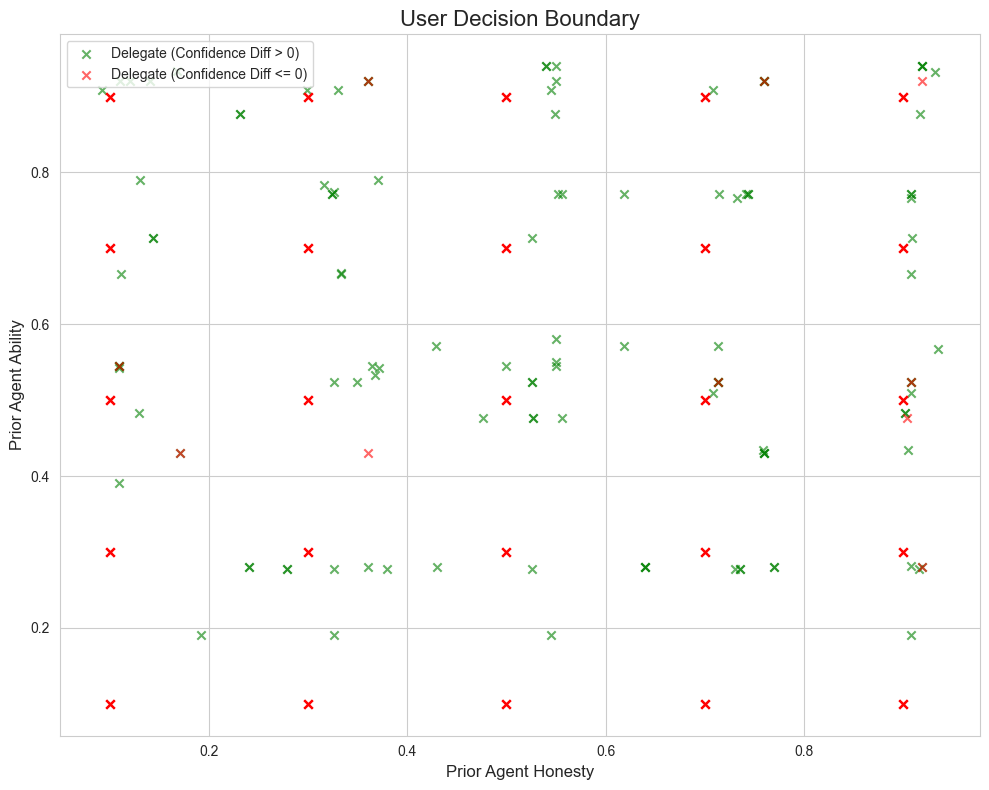

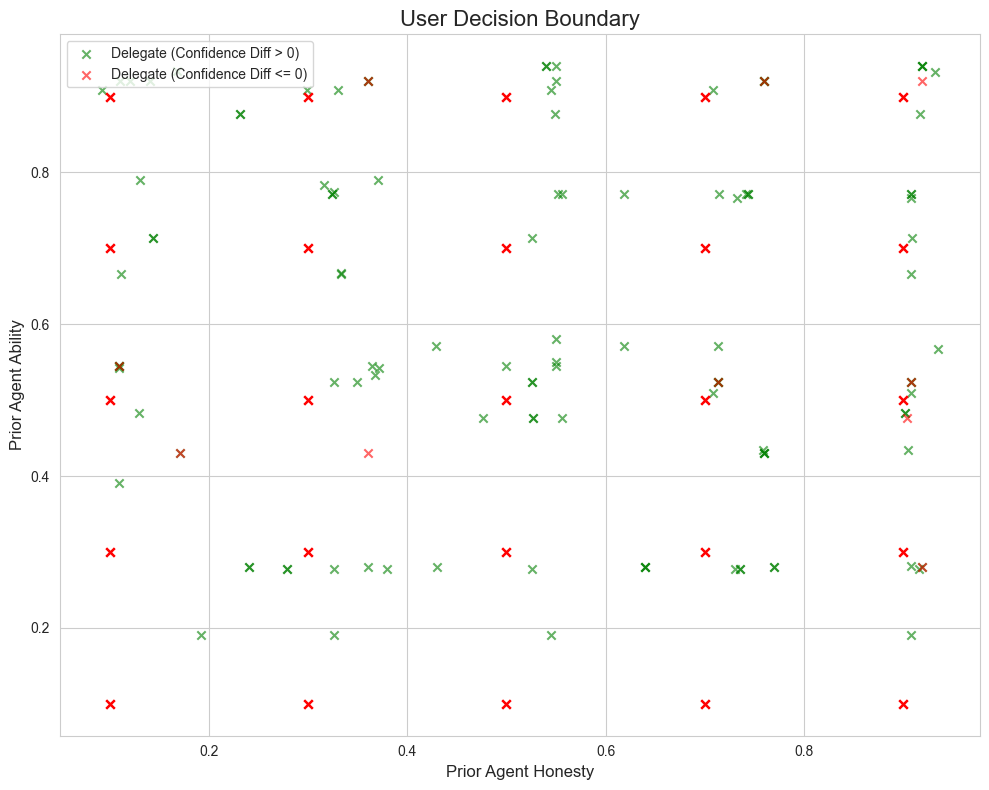

In [30]:
# Plot 4: Decision boundary scatter plot
fig, ax = plt.subplots(figsize=(10, 8))

# Define colors and markers
colors = {True: "green", False: "red"}  # For confidence_diff > 0
markers = {"DELEGATE": "x", "SELF_SOLVE": "o"}
labels = {
    ("green", "x"): "Delegate (Confidence Diff > 0)",
    ("green", "o"): "Self-Serve (Confidence Diff > 0)",
    ("red", "x"): "Delegate (Confidence Diff <= 0)",
    ("red", "o"): "Self-Serve (Confidence Diff <= 0)",
}
plotted_labels = set()

for is_positive, color in colors.items():
    for decision, marker in markers.items():
        mask = (plotting_data["user_decision"] == decision) & (
            plotting_data["confidence_diff"] > 0 if is_positive else plotting_data["confidence_diff"] <= 0
        )

        df_subset = plotting_data[mask]

        if not df_subset.empty:
            label_key = (color, marker)
            label = labels[label_key]
            if label not in plotted_labels:
                ax.scatter(
                    df_subset["prior_agent_honesty"],
                    df_subset["prior_agent_ability"],
                    color=color,
                    marker=marker,
                    label=label,
                    alpha=0.6,
                )
                plotted_labels.add(label)
            else:
                ax.scatter(
                    df_subset["prior_agent_honesty"],
                    df_subset["prior_agent_ability"],
                    color=color,
                    marker=marker,
                    alpha=0.6,
                )

ax.set_xlabel("Prior Agent Honesty", fontsize=12)
ax.set_ylabel("Prior Agent Ability", fontsize=12)
ax.set_title("User Decision Boundary", fontsize=16)
ax.legend(loc="upper left", fontsize=10)
fig.tight_layout()
display(fig)

# Store for save cell
fig4 = fig
decision_boundary_plot_path = (
    Path(SAVE_DIR) / "decision_boundary_plots" / f"decision_boundary_scatter_{int(time.time())}.pdf"
)

In [ ]:
# Save Plot 4 (run only if satisfied with the plot above)
if decision_boundary_plot_path:
    out_dir = decision_boundary_plot_path.parent
    out_dir.mkdir(parents=True, exist_ok=True)
    fig4.savefig(decision_boundary_plot_path, dpi=300)
    print("Saved:", decision_boundary_plot_path)